In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

def standardize_data(x):
    mean = x.mean(dim=1, keepdim=True)
    std = x.std(dim=1, keepdim=True) + 1e-6
    return (x - mean) / std

def augment_data(x, pattern_aug_rate=0.1, value_aug_rate=0.1):
    x_aug = x.clone()
    batch, window_size = x.shape
    for i in range(batch):
        if np.random.rand() < pattern_aug_rate:
            j = np.random.randint(0, batch)

            sub_win = np.random.randint(window_size // 4, window_size // 2)
            start = np.random.randint(0, window_size - sub_win)
            x_aug[i, start:start+sub_win] = x[j, start:start+sub_win]

    for i in range(batch):
        for t in range(window_size):
            if np.random.rand() < value_aug_rate:

                x_aug[i, t] = np.random.uniform(3.0, 5.0)
    return x_aug

class GFM(nn.Module):

    def __init__(self, window_size, embedding_dim, dropout=0.2):
        super(GFM, self).__init__()
        self.window_size = window_size
        self.embedding_dim = embedding_dim
        self.fc = nn.Linear(window_size, embedding_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x: (batch, window_size)

        fft_x = torch.fft.fft(x, dim=1)
        mag = torch.abs(fft_x)

        feat = self.fc(mag)
        feat = self.dropout(feat)
        return feat  # shape: (batch, embedding_dim)

class LFM(nn.Module):

    def __init__(self, window_size, small_win_size, embedding_dim, dropout=0.2):
        super(LFM, self).__init__()
        self.window_size = window_size
        self.small_win_size = small_win_size
        self.embedding_dim = embedding_dim

        self.fc = nn.Linear(small_win_size, embedding_dim)
        self.dropout = nn.Dropout(dropout)

        self.attn_query = nn.Parameter(torch.randn(embedding_dim))
        
    def forward(self, x):
        # x: (batch, window_size)
        batch, win_size = x.shape

        n_windows = win_size // self.small_win_size
        x = x[:, :n_windows*self.small_win_size]
        windows = x.view(batch, n_windows, self.small_win_size)  # (batch, n_windows, small_win_size)

        fft_windows = torch.fft.fft(windows, dim=2)
        mag_windows = torch.abs(fft_windows)  # (batch, n_windows, small_win_size)
 
        local_feats = self.fc(mag_windows)  # (batch, n_windows, embedding_dim)
        local_feats = self.dropout(local_feats)

        Q = local_feats[:, -1, :]  # (batch, embedding_dim)

        attn_scores = torch.bmm(local_feats, Q.unsqueeze(2)).squeeze(2)  # (batch, n_windows)
        attn_weights = F.softmax(attn_scores, dim=1)  # (batch, n_windows)

        attn_weights = attn_weights.unsqueeze(2)  # (batch, n_windows, 1)
        local_agg = torch.sum(local_feats * attn_weights, dim=1)  # (batch, embedding_dim)
        return local_agg

class Encoder(nn.Module):
    def __init__(self, input_dim, cond_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim + cond_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
    def forward(self, x, cond):
        # x: (batch, input_dim), cond: (batch, cond_dim)
        x_cond = torch.cat([x, cond], dim=1)
        h = F.relu(self.fc1(x_cond))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim, cond_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim + cond_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, z, cond):
        z_cond = torch.cat([z, cond], dim=1)
        h = F.relu(self.fc1(z_cond))
        out = self.fc_out(h)
        return out

class FCVAE(nn.Module):
    def __init__(self, window_size, small_win_size, 
                 input_dim=1, cond_embedding_dim=32, 
                 encoder_hidden=64, latent_dim=16, decoder_hidden=64, dropout=0.2):
        super(FCVAE, self).__init__()
        self.window_size = window_size
        self.input_dim = input_dim
        
        # (batch, window_size)
        self.gfm = GFM(window_size, cond_embedding_dim, dropout=dropout)
        self.lfm = LFM(window_size, small_win_size, cond_embedding_dim, dropout=dropout)

        self.encoder = Encoder(window_size, 2 * cond_embedding_dim, encoder_hidden, latent_dim)
        self.decoder = Decoder(latent_dim, 2 * cond_embedding_dim, decoder_hidden, window_size)
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def forward(self, x):
        cond_global = self.gfm(x)       # (batch, cond_embedding_dim)
        cond_local = self.lfm(x)        # (batch, cond_embedding_dim)
        cond = torch.cat([cond_global, cond_local], dim=1)  # (batch, 2*cond_embedding_dim)
        
        mu, logvar = self.encoder(x, cond)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z, cond)
        return recon, mu, logvar

def loss_function(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss


def train_fcvvae(model, dataloader, optimizer, num_epochs=50, beta=1.0, device='cpu'):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch in dataloader:
            x = batch[0].to(device)
            x = standardize_data(x)
            x = augment_data(x, pattern_aug_rate=0.1, value_aug_rate=0.1)
            
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss = loss_function(recon, x, mu, logvar, beta)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader.dataset)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

if __name__ == '__main__':

    window_size = 128
    small_win_size = 16
    num_samples = 1000

    t = np.linspace(0, 2*np.pi, window_size)
    data = []
    for _ in range(num_samples):
        phase = np.random.rand() * 2 * np.pi
        amplitude = np.random.rand() * 2 + 0.5
        signal = amplitude * np.sin(t + phase)
        data.append(signal)
    data = np.array(data, dtype=np.float32)  # shape: (num_samples, window_size)
    data_tensor = torch.from_numpy(data)
    
    dataset = TensorDataset(data_tensor)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = FCVAE(window_size=window_size, small_win_size=small_win_size,
                  input_dim=1, cond_embedding_dim=32,
                  encoder_hidden=64, latent_dim=16, decoder_hidden=64, dropout=0.2)
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    train_fcvvae(model, dataloader, optimizer, num_epochs=50, beta=0.5, device=device)


Epoch [1/50], Loss: 362.6725
Epoch [2/50], Loss: 317.6794
Epoch [3/50], Loss: 307.0479
Epoch [4/50], Loss: 299.5449
Epoch [5/50], Loss: 285.5093
Epoch [6/50], Loss: 268.6967
Epoch [7/50], Loss: 263.5582
Epoch [8/50], Loss: 262.9574
Epoch [9/50], Loss: 259.3293
Epoch [10/50], Loss: 258.7512
Epoch [11/50], Loss: 255.3881
Epoch [12/50], Loss: 241.3347
Epoch [13/50], Loss: 215.6280
Epoch [14/50], Loss: 212.8426
Epoch [15/50], Loss: 210.3823
Epoch [16/50], Loss: 206.6435
Epoch [17/50], Loss: 207.8392
Epoch [18/50], Loss: 210.0945
Epoch [19/50], Loss: 213.0075
Epoch [20/50], Loss: 209.3055
Epoch [21/50], Loss: 210.1361
Epoch [22/50], Loss: 211.1922
Epoch [23/50], Loss: 207.6026
Epoch [24/50], Loss: 209.3711
Epoch [25/50], Loss: 208.9282
Epoch [26/50], Loss: 207.6966
Epoch [27/50], Loss: 206.9473
Epoch [28/50], Loss: 210.8435
Epoch [29/50], Loss: 207.4662
Epoch [30/50], Loss: 209.2081
Epoch [31/50], Loss: 212.9344
Epoch [32/50], Loss: 208.0075
Epoch [33/50], Loss: 206.9465
Epoch [34/50], Loss

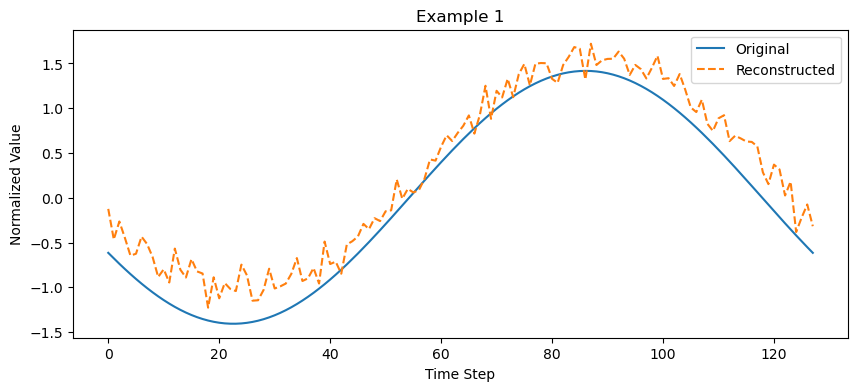

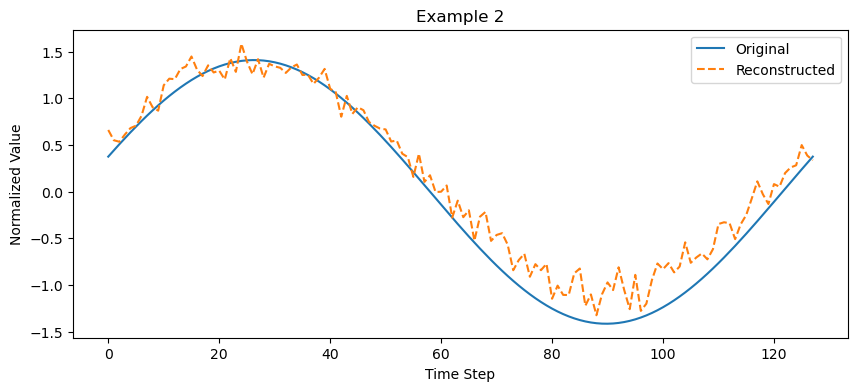

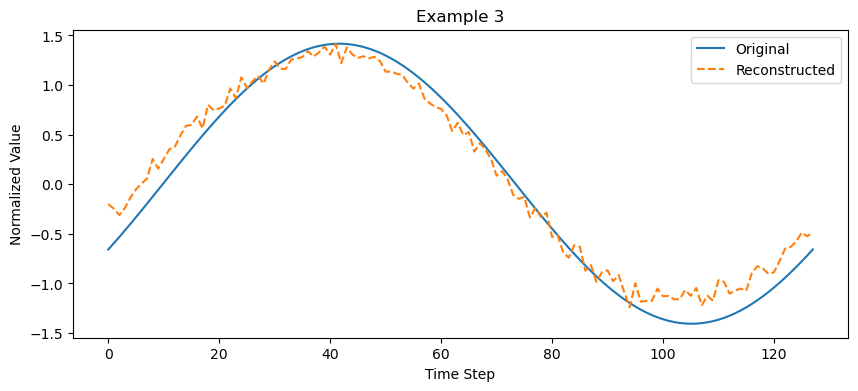

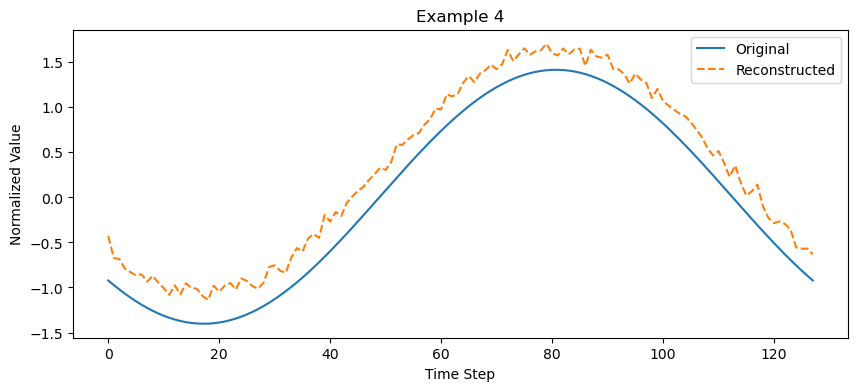

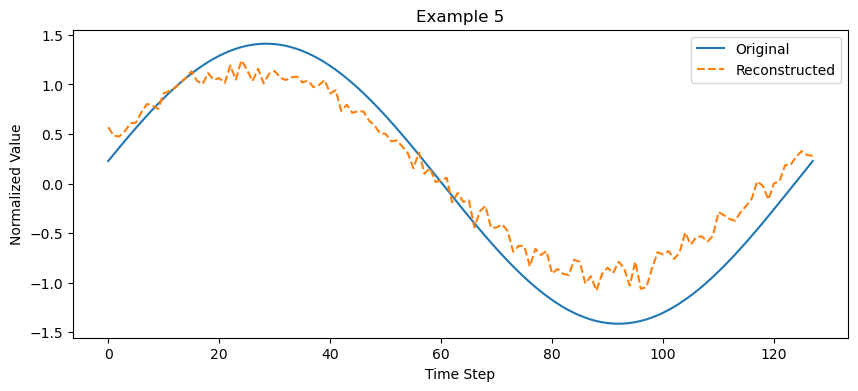

In [ ]:
import matplotlib.pyplot as plt

def demo_fcvvae(model, dataloader, device='cpu', num_examples=5):
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            # batch[0] shape: (batch_size, window_size)
            x = batch[0].to(device)
            x_std = standardize_data(x)
            recon, mu, logvar = model(x_std)
            x_std_np = x_std.cpu().numpy()
            recon_np = recon.cpu().numpy()
            break

    for i in range(num_examples):
        plt.figure(figsize=(10, 4))
        plt.plot(x_std_np[i], label='Original')
        plt.plot(recon_np[i], label='Reconstructed', linestyle='--')
        plt.title(f'Example {i+1}')
        plt.xlabel('Time Step')
        plt.ylabel('Normalized Value')
        plt.legend()
        plt.show()

demo_fcvvae(model, dataloader, device=device, num_examples=5)